In [ ]:
!pip install segmentation_models_pytorch --quiet

import os
import cv2
import copy
import random
import shutil
import warnings
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter

import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp

warnings.filterwarnings("ignore")

# Cấu hình đường dẫn cho CAMO Dataset
BASE_DIR = '/kaggle/input/datasets/quanganhnguynquc/camodataset/CAMO-V.1.0-CVIU2019'
TRAIN_IMG_DIR = os.path.join(BASE_DIR, 'Images/Train')
TEST_IMG_DIR = os.path.join(BASE_DIR, 'Images/Test')
GT_DIR = os.path.join(BASE_DIR, 'GT')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 10.1 MB/s eta 0:00:00


2026-06-09 18:10:23.263726: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781028623.474617      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781028623.534103      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781028624.002781      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781028624.002823      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781028624.002826      57 computation_placer.cc:177] computation placer alr

In [ ]:
def img_transform(trainsize=256):
    train_transform = A.Compose([
        A.Rotate([-10, 10]),
        A.RandomScale([0.5, 2]),
        A.HorizontalFlip(),
        A.GaussNoise(var_limit=(10, 50), p=0.5),
        A.GridDistortion(num_steps=5, distort_limit=0.3),
        A.Resize(width=trainsize, height=trainsize),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225), max_pixel_value=255.0),
        ToTensorV2(),
    ])

    test_transform = A.Compose([
        A.Resize(width=trainsize, height=trainsize),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225), max_pixel_value=255.0),
        ToTensorV2(),
    ])
    return train_transform, test_transform

class CamoDataset(Dataset):
    def __init__(self, images_dir, masks_dir, transform=None):
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.transform = transform
        self.image_names = [f for f in os.listdir(images_dir) if f.endswith(('.png', '.jpg', '.jpeg'))]

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        img_name = self.image_names[idx]
        img_path = os.path.join(self.images_dir, img_name)

        base_name = os.path.splitext(img_name)[0]
        mask_name = base_name + ".png"
        mask_path = os.path.join(self.masks_dir, mask_name)

        image = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        if self.transform is not None:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        # CHÚ Ý ĐIỂM NÀY: Chuyển [0, 255] thành [0.0, 1.0] và ép kiểu Float
        mask = mask.clone().detach() / 255.0
        mask = mask.float()

        return image, mask

In [ ]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0, restore_best_weights=False):
        self.patience = patience
        self.min_delta = min_delta
        self.restore_best_weights = restore_best_weights
        self.best_model = None
        self.best_loss = None
        self.counter = 0
        self.status = ""

    def __call__(self, model, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.best_model = copy.deepcopy(model.state_dict())
        elif self.best_loss - val_loss > self.min_delta:
            self.best_model = copy.deepcopy(model.state_dict())
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.status = f"Stop on {self.counter}"
                if self.restore_best_weights:
                    model.load_state_dict(self.best_model)
                return True
        self.status = f"{self.counter}/{self.patience}"
        return False

class AverageMeter(object):
    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

def intersectionAndUnionGPU(output, target, K, ignore_index=255):
    assert (output.dim() in [1, 2, 3])
    assert output.shape == target.shape
    output = output.view(-1)
    target = target.view(-1)
    output[target == ignore_index] = ignore_index
    intersection = output[output == target]
    area_intersection = torch.histc(intersection, bins=K, min=0, max=K-1)
    area_output = torch.histc(output, bins=K, min=0, max=K-1)
    area_target = torch.histc(target, bins=K, min=0, max=K-1)
    area_union = area_output + area_target - area_intersection
    return area_intersection, area_union, area_target

In [ ]:
def evaluate(model, val_dataloader, device, num_classes, intersection_meter, union_meter, target_meter):
    model.eval()
    with torch.no_grad():
        for idx, (img, mask) in enumerate(val_dataloader):
            img = img.to(device).float()

            # Mask đang có 4 chiều (B, 1, H, W)
            mask = mask.to(device).float().unsqueeze(1)

            # y_pred cũng có 4 chiều (B, 1, H, W)
            y_pred = model(img)

            # Biến đổi giá trị dự đoán về 0 và 1 (Thresholding)
            y_pred = (y_pred > 0).float()

            # --- DÒNG SỬA LỖI: Xóa bỏ chiều Channel (chiều số 1) để đưa về 3 chiều (B, H, W) ---
            y_pred = y_pred.squeeze(1)
            mask = mask.squeeze(1)
            # -----------------------------------------------------------------------------------

            # Bài toán 1 class nhưng Metric tính IntersectionAndUnion cần 2 bins (Nền và Vật thể)
            intersection, union, target = intersectionAndUnionGPU(y_pred.float(), mask.float(), num_classes + 1)
            intersection, union, target = intersection.cpu().numpy(), union.cpu().numpy(), target.cpu().numpy()

            intersection_meter.update(intersection)
            union_meter.update(union)
            target_meter.update(target)

            if idx > 40:
                break

        accuracy_class = intersection_meter.sum / (target_meter.sum + 1e-10)
        iou_class = intersection_meter.sum / (union_meter.sum + 1e-10)
        dice_class = (2 * intersection_meter.sum) / (intersection_meter.sum + union_meter.sum + 1e-10)

        macc = np.mean(accuracy_class)
        miou = np.mean(iou_class)
        mdice = np.mean(dice_class)

        return macc, miou, mdice

In [ ]:
import cv2
import numpy as np

# Đọc thử 1 ảnh mask bất kỳ trong tập dataset của bạn
mask = cv2.imread('/kaggle/input/datasets/quanganhnguynquc/camodataset/CAMO-V.1.0-CVIU2019/GT/camourflage_00001.png', cv2.IMREAD_GRAYSCALE)

print("Các con số có mặt trong mask là:", np.unique(mask))

Các con số có mặt trong mask là: [  0 255]


In [ ]:
from tqdm import tqdm

def train(model, train_dataloader, device, optimizer, epoch, epochs, writer, train_loss_meter, criterion):
    model.train()

    loop = tqdm(train_dataloader, desc=f"Epoch [{epoch + 1}/{epochs}]")

    for batch_idx, (images, masks) in enumerate(loop):
        images = images.to(device).float()
        masks = masks.to(device).float()

        # Nếu mask đang có shape [B, H, W] thì thêm channel thành [B, 1, H, W]
        if masks.ndim == 3:
            masks = masks.unsqueeze(1)

        # Nếu mask có giá trị 0-255 thì đưa về 0-1
        if masks.max() > 1:
            masks = masks / 255.0

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, masks)

        loss.backward()
        optimizer.step()

        train_loss_meter.update(loss.item(), images.size(0))

        global_step = epoch * len(train_dataloader) + batch_idx
        writer.add_scalar("Train/Loss", loss.item(), global_step)

        loop.set_postfix({
            "loss": f"{train_loss_meter.avg:.4f}"
        })

In [ ]:
def main(learning_rate, batch_size, epochs, num_workers, model_save_path, tensorboard_path, num_classes):
    if not os.path.exists(model_save_path):
        os.makedirs(model_save_path)
    if not os.path.exists(tensorboard_path):
        os.makedirs(tensorboard_path)

    train_transform, test_transform = img_transform(trainsize=256)

    train_dataset = CamoDataset(images_dir=TRAIN_IMG_DIR, masks_dir=GT_DIR, transform=train_transform)
    valid_dataset = CamoDataset(images_dir=TEST_IMG_DIR, masks_dir=GT_DIR, transform=test_transform)

    train_dataloader = DataLoader(train_dataset, batch_size=batch_size, num_workers=num_workers, shuffle=True, drop_last=True)
    val_dataloader = DataLoader(valid_dataset, batch_size=batch_size, num_workers=num_workers, shuffle=False, drop_last=False)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Đang huấn luyện trên thiết bị: {device}")

    model = smp.Unet(encoder_name="resnext101_32x8d", in_channels=3, classes=num_classes)
    model.to(device)

    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # SỬA LẠI: Trở về dùng Loss nhị phân
    criterion = nn.BCEWithLogitsLoss()

    best_predict = -1.0
    current_epoch = 0

    train_loss_meter = AverageMeter()
    intersection_meter = AverageMeter()
    union_meter = AverageMeter()
    target_meter = AverageMeter()

    es = EarlyStopping(patience=10, restore_best_weights=False)
    es.best_loss = 1 - best_predict

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=4, threshold=1e-4, min_lr=0)
    writer = SummaryWriter(tensorboard_path)

    for epoch in range(current_epoch, epochs):
        train_loss_meter.reset()
        intersection_meter.reset()
        union_meter.reset()
        target_meter.reset()

        train(model, train_dataloader, device, optimizer, epoch, epochs, writer, train_loss_meter, criterion)
        acc, miou, dice = evaluate(model, val_dataloader, device, num_classes, intersection_meter, union_meter, target_meter)

        writer.add_scalar("Test/Acc", acc, epoch)
        writer.add_scalar("Test/mIOU", miou, epoch)
        writer.add_scalar("Test/Dice", dice, epoch)

        scheduler.step(1 - miou)

        checkpoint = {
            "model_state_dict": model.state_dict(),
            "epoch": epoch,
            "optimizer_state_dict": optimizer.state_dict(),
            "dice": dice,
            "miou": miou
        }

        torch.save(checkpoint, os.path.join(model_save_path, "model_last.pth"))

        if miou > best_predict:
            torch.save(checkpoint, os.path.join(model_save_path, "model_best.pth"))
            best_predict = miou
            print(f"Lưu model mới tốt nhất với mIoU: {best_predict:.4f}")

        if es(model, 1 - miou):
            print(f"Dừng sớm tại epoch {epoch + 1}")
            break

        print(f"VAL| Acc:{acc:.4f} | mIOU: {miou:.4f} | Dice: {dice:.4f} | EStop: {es.status}")

if __name__ == '__main__':
    LEARNING_RATE = 1e-4
    BATCH_SIZE = 16
    EPOCHS = 100
    NUM_WORKERS = os.cpu_count()
    MODEL_SAVE_PATH = "/kaggle/working/trained_model"
    TENSORBOARD_PATH = "/kaggle/working/tensorboard"

    # SỬA LẠI: Trở về 1 class
    NUM_CLASSES = 1

    main(LEARNING_RATE, BATCH_SIZE, EPOCHS, NUM_WORKERS, MODEL_SAVE_PATH, TENSORBOARD_PATH, NUM_CLASSES)

Đang huấn luyện trên thiết bị: cuda


Epoch [1/100]: 100%|██████████| 62/62 [01:10<00:00,  1.13s/it, loss=0.4833]


Lưu model mới tốt nhất với mIoU: 0.6466
VAL| Acc:0.7539 | mIOU: 0.6466 | Dice: 0.7661 | EStop: 0/10


Epoch [2/100]: 100%|██████████| 62/62 [01:11<00:00,  1.15s/it, loss=0.3345]


Lưu model mới tốt nhất với mIoU: 0.6745
VAL| Acc:0.7543 | mIOU: 0.6745 | Dice: 0.7877 | EStop: 0/10


...

VAL| Acc:0.8202 | mIOU: 0.7502 | Dice: 0.8481 | EStop: 8/10


Epoch [48/100]: 100%|██████████| 62/62 [01:08<00:00,  1.11s/it, loss=0.0971]


VAL| Acc:0.8274 | mIOU: 0.7553 | Dice: 0.8520 | EStop: 9/10


Epoch [49/100]: 100%|██████████| 62/62 [01:18<00:00,  1.26s/it, loss=0.0969]


Dừng sớm tại epoch 49


In [ ]:
class UnNormalize(object):
    def __init__(self, mean, std):
        self.mean = mean
        self.std = std

    def __call__(self, tensor):
        tensor = tensor.clone()
        for t, m, s in zip(tensor, self.mean, self.std):
            t.mul_(s).add_(m)
        return tensor


def pred_show_image_grid(model_pth, device, test_transform, num_classes=1, num_imgs=5):
    checkpoint = torch.load(model_pth, map_location=device, weights_only=False)

    # Khởi tạo lại đúng kiến trúc model đã train
    model = smp.Unet(
        encoder_name="resnext101_32x8d",
        in_channels=3,
        classes=num_classes
    )

    # Load trọng số
    if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        model.load_state_dict(checkpoint["model_state_dict"])
    else:
        model.load_state_dict(checkpoint)

    model.to(device)
    model.eval()

    # Đọc dữ liệu test
    image_dataset = CamoDataset(
        images_dir=TEST_IMG_DIR,
        masks_dir=GT_DIR,
        transform=test_transform
    )

    unorm = UnNormalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    )

    # Chọn ảnh ngẫu nhiên
    if isinstance(num_imgs, int):
        num_imgs = min(num_imgs, len(image_dataset))
        selected_ids = np.random.choice(len(image_dataset), num_imgs, replace=False)
    else:
        selected_ids = num_imgs

    images, orig_masks, pred_masks = [], [], []

    with torch.no_grad():
        for idx in selected_ids:
            ori_img, mask = image_dataset[idx]

            img = ori_img.to(device).float().unsqueeze(0)

            y_pred = model(img)

            # Chuyển logits sang xác suất rồi threshold
            y_pred = torch.sigmoid(y_pred)
            y_pred = (y_pred > 0.5).float()

            image = unorm(ori_img).permute(1, 2, 0).cpu().numpy()
            image = np.clip(image, 0, 1)

            images.append(image)
            orig_masks.append(mask.squeeze().cpu().numpy())
            pred_masks.append(y_pred.squeeze().cpu().numpy())

    # Vẽ kết quả
    fig, axes = plt.subplots(3, len(selected_ids), figsize=(4 * len(selected_ids), 10))

    # Nếu chỉ hiển thị 1 ảnh thì axes cần reshape lại
    if len(selected_ids) == 1:
        axes = np.expand_dims(axes, axis=1)

    titles = ["Original Image", "Ground Truth Mask", "Predicted Mask"]

    for i in range(len(selected_ids)):
        axes[0, i].imshow(images[i])
        axes[0, i].set_title(titles[0], fontsize=14, fontweight="bold")
        axes[0, i].axis("off")

        axes[1, i].imshow(orig_masks[i], cmap="gray")
        axes[1, i].set_title(titles[1], fontsize=14, fontweight="bold")
        axes[1, i].axis("off")

        axes[2, i].imshow(pred_masks[i], cmap="gray")
        axes[2, i].set_title(titles[2], fontsize=14, fontweight="bold")
        axes[2, i].axis("off")

    plt.tight_layout()
    plt.show()

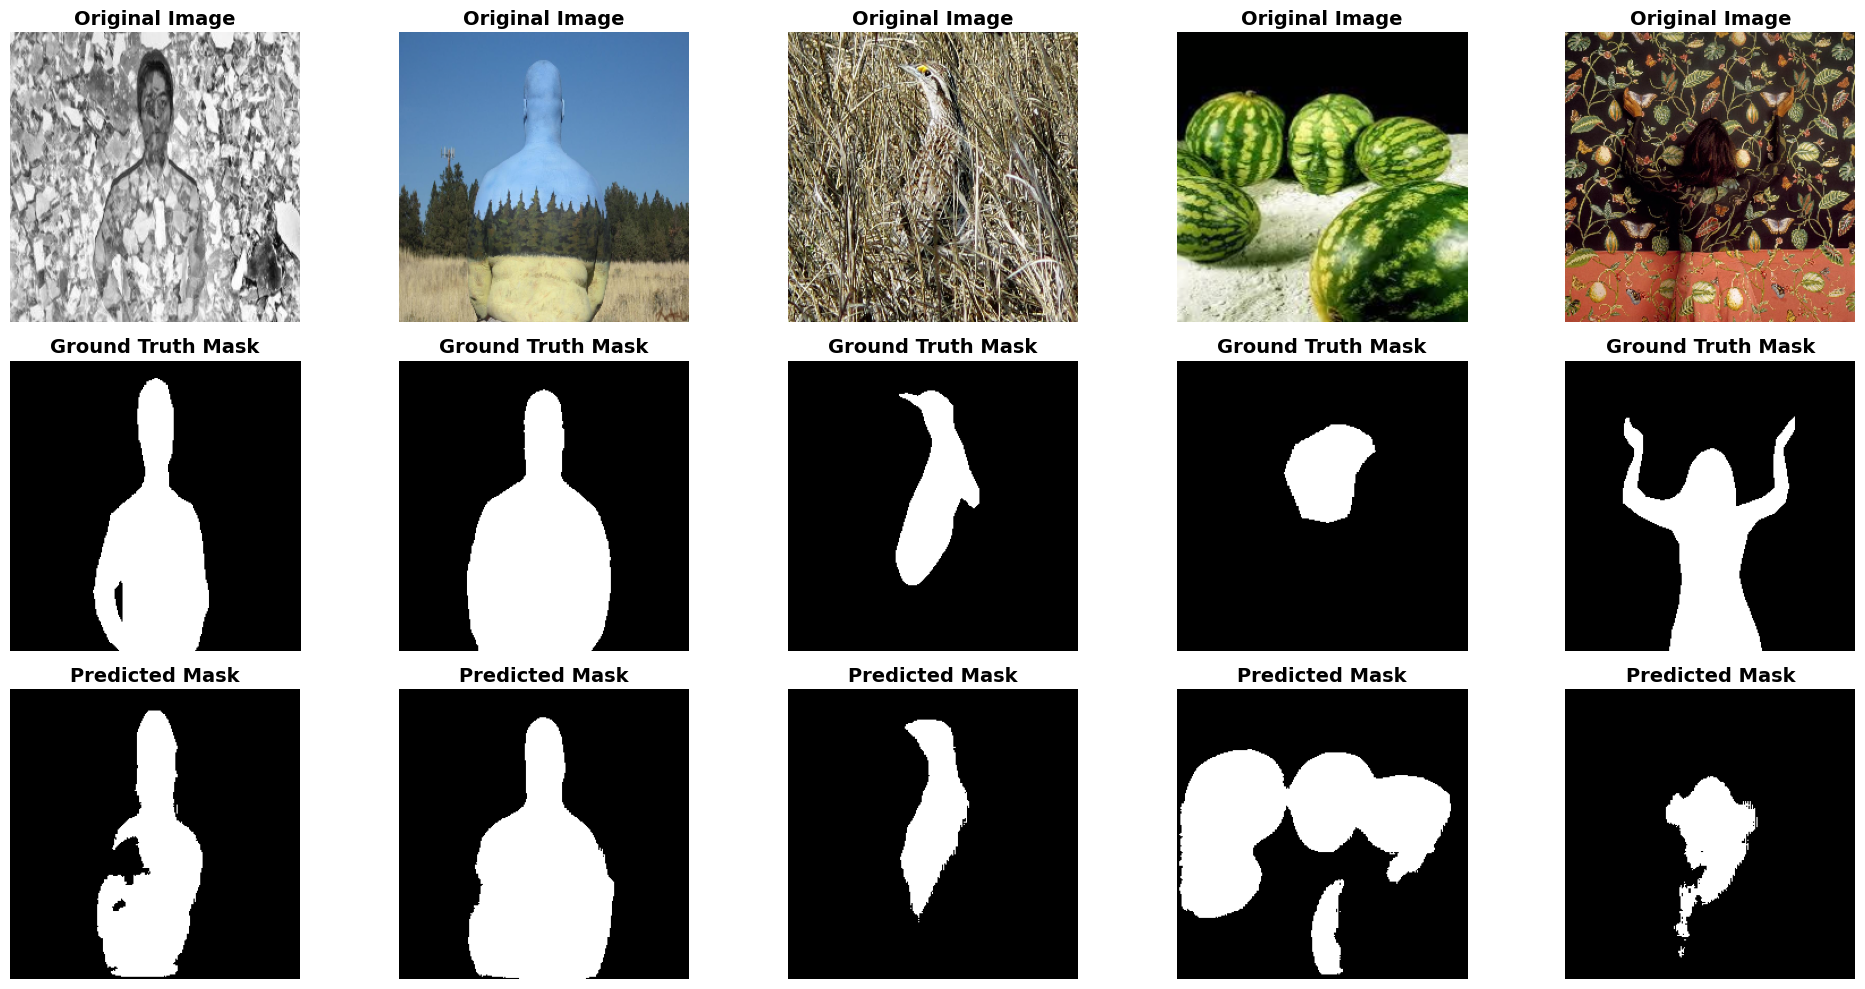

In [ ]:
_, test_transform = img_transform()

model_pth = "/kaggle/working/trained_model/model_best.pth"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

if os.path.exists(model_pth):
    pred_show_image_grid(
        model_pth=model_pth,
        device=DEVICE,
        test_transform=test_transform,
        num_classes=1,
        num_imgs=5
    )
else:
    print(f"Chưa tìm thấy model tại {model_pth}.")